In [1]:
from google.colab import files

uploaded = files.upload()

Saving district wise rainfall normal.csv to district wise rainfall normal.csv


In [2]:
import os

os.listdir()

['.config', 'district wise rainfall normal.csv', 'sample_data']

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
file_path = "district wise rainfall normal.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1


In [6]:
df.shape

(641, 19)

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 641
Columns: 19


In [8]:
df.columns

Index(['STATE_UT_NAME', 'DISTRICT', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
       'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb',
       'Mar-May', 'Jun-Sep', 'Oct-Dec'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STATE_UT_NAME  641 non-null    object 
 1   DISTRICT       641 non-null    object 
 2   JAN            641 non-null    float64
 3   FEB            641 non-null    float64
 4   MAR            641 non-null    float64
 5   APR            641 non-null    float64
 6   MAY            641 non-null    float64
 7   JUN            641 non-null    float64
 8   JUL            641 non-null    float64
 9   AUG            641 non-null    float64
 10  SEP            641 non-null    float64
 11  OCT            641 non-null    float64
 12  NOV            641 non-null    float64
 13  DEC            641 non-null    float64
 14  ANNUAL         641 non-null    float64
 15  Jan-Feb        641 non-null    float64
 16  Mar-May        641 non-null    float64
 17  Jun-Sep        641 non-null    float64
 18  Oct-Dec   

In [10]:
df.describe()

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
count,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.00000,641.000000
mean,18.355070,20.984399,30.034789,45.543214,81.535101,196.007332,326.033697,291.152262,194.609048,90.446334,34.117473,18.150858,1346.969579,39.339470,157.113105,1007.80234,142.714665
std,21.082806,27.729596,45.451082,71.556279,111.960390,196.556284,221.364643,152.647325,99.830540,74.990685,59.371274,32.711009,838.878874,47.212773,213.445888,629.33261,148.951752
min,0.000000,0.000000,0.000000,0.000000,0.900000,3.800000,11.600000,14.100000,8.600000,3.100000,1.200000,0.000000,94.600000,0.000000,1.500000,39.60000,5.600000
25%,6.900000,7.000000,7.000000,5.000000,12.100000,68.800000,206.400000,194.600000,128.800000,34.300000,6.600000,5.300000,830.400000,14.700000,27.800000,625.40000,51.600000
50%,13.300000,12.300000,12.700000,15.100000,33.900000,131.900000,293.700000,284.800000,181.300000,62.600000,12.900000,7.900000,1116.200000,27.700000,67.200000,896.60000,86.700000
75%,19.200000,24.100000,33.200000,48.300000,91.900000,226.600000,374.800000,358.100000,234.100000,130.200000,32.300000,14.900000,1530.900000,41.100000,172.400000,1193.80000,175.200000
max,144.500000,229.600000,367.900000,554.400000,733.700000,1476.200000,1820.900000,1522.100000,826.300000,517.700000,475.100000,297.700000,7229.300000,335.300000,1256.500000,5228.00000,1048.500000


In [11]:
df.isnull().sum()

,0
STATE_UT_NAME,0
DISTRICT,0
JAN,0
FEB,0
MAR,0
APR,0
MAY,0
JUN,0
JUL,0
AUG,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
rename_columns = {
    "STATE_UT_NAME": "State",
    "DISTRICT": "District",
    "JAN": "Jan",
    "FEB": "Feb",
    "MAR": "Mar",
    "APR": "Apr",
    "MAY": "May",
    "JUN": "Jun",
    "JUL": "Jul",
    "AUG": "Aug",
    "SEP": "Sep",
    "OCT": "Oct",
    "NOV": "Nov",
    "DEC": "Dec",
    "ANNUAL": "Annual_Rainfall",
    "Jan-Feb": "Jan_Feb",
    "Mar-May": "Mar_May",
    "Jun-Sep": "Jun_Sep",
    "Oct-Dec": "Oct_Dec"
}

df.rename(columns=rename_columns, inplace=True)

df.head()

,State,District,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual_Rainfall,Jan_Feb,Mar_May,Jun_Sep,Oct_Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1


In [14]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
State              0
District           0
Jan                0
Feb                0
Mar                0
Apr                0
May                0
Jun                0
Jul                0
Aug                0
Sep                0
Oct                0
Nov                0
Dec                0
Annual_Rainfall    0
Jan_Feb            0
Mar_May            0
Jun_Sep            0
Oct_Dec            0
dtype: int64


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
monthly_columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

for col in monthly_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [17]:
df[monthly_columns].dtypes

,0
Jan,float64
Feb,float64
Mar,float64
Apr,float64
May,float64
Jun,float64
Jul,float64
Aug,float64
Sep,float64
Oct,float64


In [18]:
df["Calculated_Annual"] = df[monthly_columns].sum(axis=1)

df["Annual_Difference"] = (
    df["Annual_Rainfall"] -
    df["Calculated_Annual"]
).abs()

print(
    "Maximum difference:",
    df["Annual_Difference"].max()
)

Maximum difference: 9.094947017729282e-13


In [19]:
df[
    ["Annual_Rainfall",
     "Calculated_Annual",
     "Annual_Difference"]
].head()

,Annual_Rainfall,Calculated_Annual,Annual_Difference
0,2805.2,2805.2,4.547474e-13
1,3015.7,3015.7,4.547474e-13
2,2913.3,2913.3,0.000000e+00
3,3043.8,3043.8,0.000000e+00
4,4034.7,4034.7,4.547474e-13


In [20]:
df.drop(
    columns=[
        "Calculated_Annual",
        "Annual_Difference"
    ],
    inplace=True
)

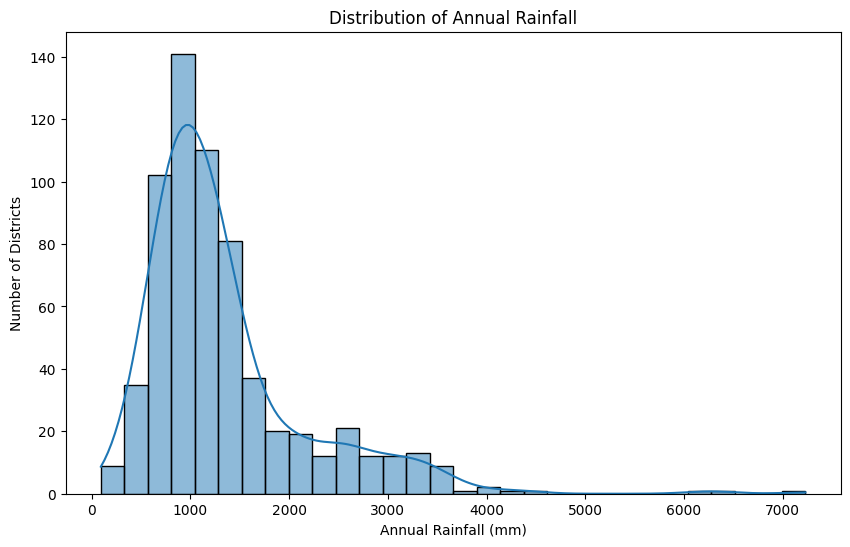

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Annual_Rainfall"],
    bins=30,
    kde=True
)

plt.title("Distribution of Annual Rainfall")
plt.xlabel("Annual Rainfall (mm)")
plt.ylabel("Number of Districts")

plt.show()

In [22]:
monthly_average = df[monthly_columns].mean()

monthly_average

,0
Jan,18.355070
Feb,20.984399
Mar,30.034789
Apr,45.543214
May,81.535101
Jun,196.007332
Jul,326.033697
Aug,291.152262
Sep,194.609048
Oct,90.446334


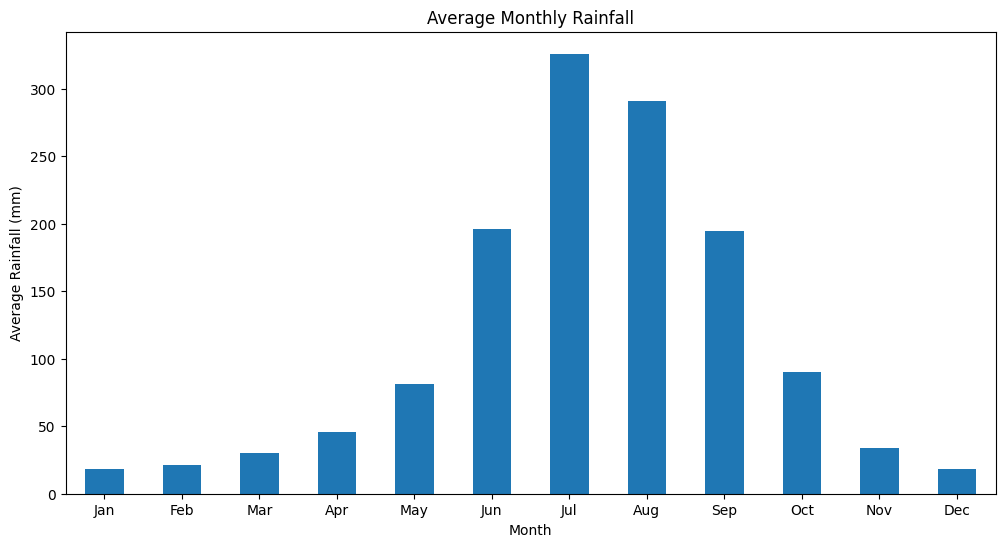

In [23]:
plt.figure(figsize=(12, 6))

monthly_average.plot(kind="bar")

plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")

plt.xticks(rotation=0)

plt.show()

In [24]:
state_rainfall = (
    df.groupby("State")["Annual_Rainfall"]
    .mean()
    .sort_values(ascending=False)
)

state_rainfall.head(10)

,Annual_Rainfall
State,
MEGHALAYA,3682.842857
GOA,3278.500000
KERALA,2937.392857
ARUNACHAL PRADESH,2927.375000
ANDAMAN And NICOBAR ISLANDS,2911.400000
SIKKIM,2838.350000
MIZORAM,2616.322222
MANIPUR,2496.633333
TRIPURA,2479.125000


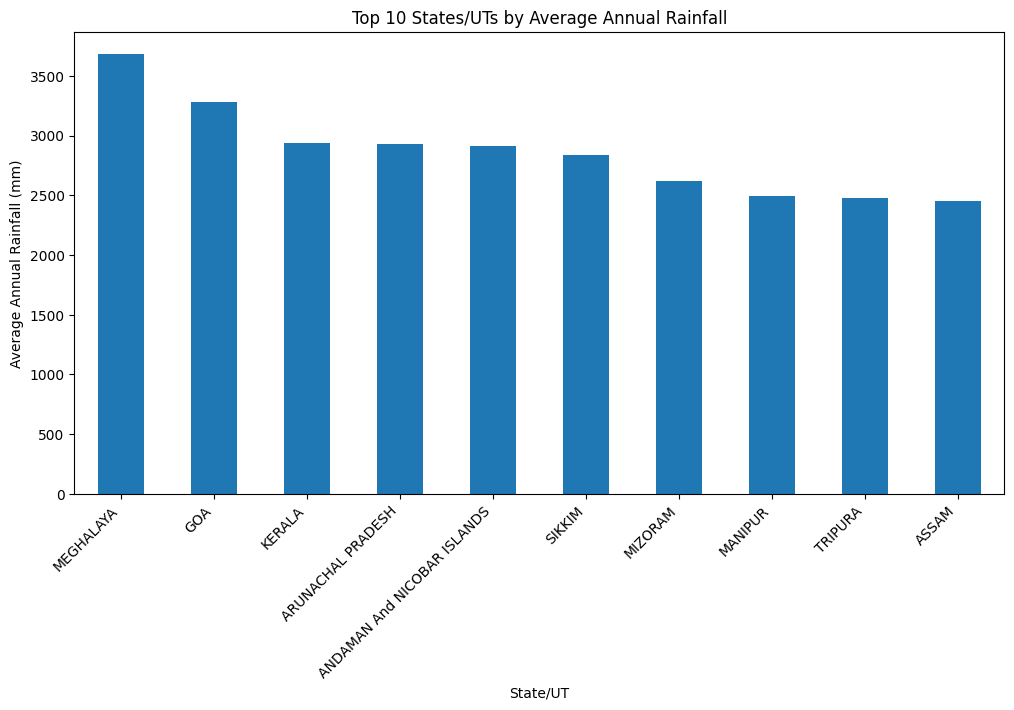

In [25]:
plt.figure(figsize=(12, 6))

state_rainfall.head(10).plot(kind="bar")

plt.title("Top 10 States/UTs by Average Annual Rainfall")
plt.xlabel("State/UT")
plt.ylabel("Average Annual Rainfall (mm)")

plt.xticks(rotation=45, ha="right")

plt.show()

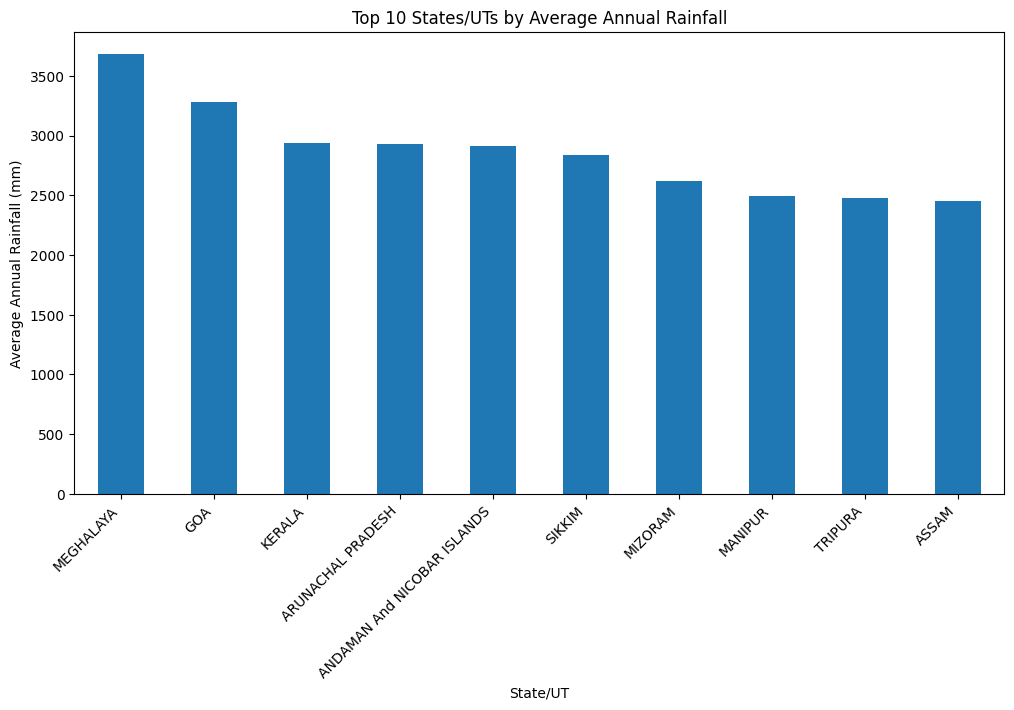

In [26]:
plt.figure(figsize=(12, 6))

state_rainfall.head(10).plot(kind="bar")

plt.title("Top 10 States/UTs by Average Annual Rainfall")
plt.xlabel("State/UT")
plt.ylabel("Average Annual Rainfall (mm)")

plt.xticks(rotation=45, ha="right")

plt.show()

In [27]:
df[
    ["State", "District", "Annual_Rainfall"]
].sort_values(
    "Annual_Rainfall",
    ascending=True
).head(10)

,State,District,Annual_Rainfall
353,JAMMU AND KASHMIR,LADAKH (LEH),94.6
374,RAJASTHAN,JAISALMER,181.2
359,JAMMU AND KASHMIR,KARGIL,223.3
373,RAJASTHAN,SRI GANGANAGA,252.9
370,RAJASTHAN,BARMER,268.6
371,RAJASTHAN,BIKANER,274.0
379,RAJASTHAN,HANUMANGARH,301.6
376,RAJASTHAN,JODHPUR,308.1
295,HARYANA,SIRSA,313.5
301,HARYANA,FATEHABAD,364.6


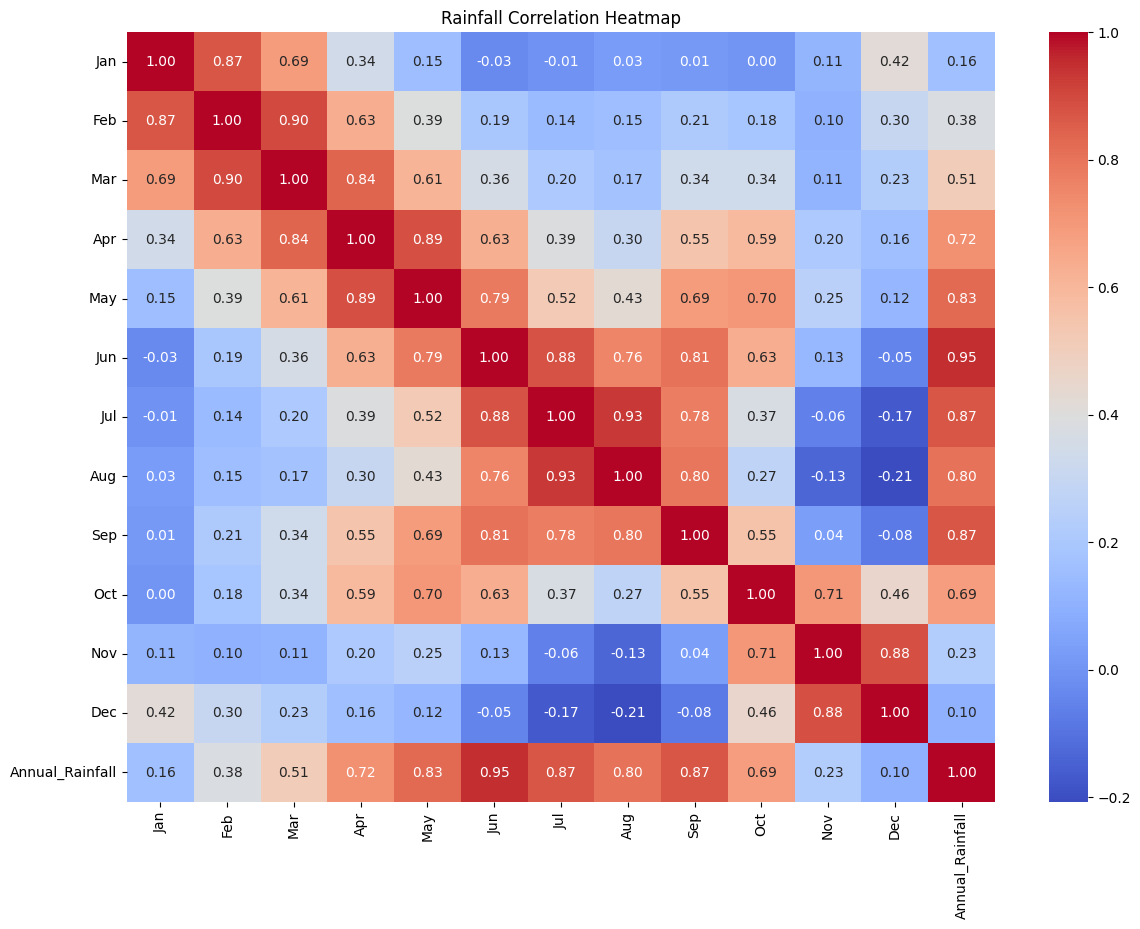

In [28]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df[monthly_columns + ["Annual_Rainfall"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Rainfall Correlation Heatmap")

plt.show()

In [29]:
df["Winter_Rainfall"] = df[
    ["Jan", "Feb"]
].sum(axis=1)

In [30]:
df["Summer_Rainfall"] = df[
    ["Mar", "Apr", "May"]
].sum(axis=1)

In [31]:
df["Monsoon_Rainfall"] = df[
    ["Jun", "Jul", "Aug", "Sep"]
].sum(axis=1)

In [32]:
df["Post_Monsoon_Rainfall"] = df[
    ["Oct", "Nov", "Dec"]
].sum(axis=1)

In [33]:
df["Max_Monthly_Rainfall"] = df[
    monthly_columns
].max(axis=1)

In [34]:
df["Min_Monthly_Rainfall"] = df[
    monthly_columns
].min(axis=1)

In [35]:
df["Rainfall_STD"] = df[
    monthly_columns
].std(axis=1)

In [36]:
df["Monsoon_Contribution"] = (
    df["Monsoon_Rainfall"] /
    df["Annual_Rainfall"]
) * 100

In [37]:
df.head()

,State,District,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,...,Jun_Sep,Oct_Dec,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,Post_Monsoon_Rainfall,Max_Monthly_Rainfall,Min_Monthly_Rainfall,Rainfall_STD,Monsoon_Contribution
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,...,1207.2,892.1,165.2,540.7,1207.2,892.1,358.5,57.9,113.818630,43.034365
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,...,1757.2,705.3,69.7,483.5,1757.2,705.3,457.2,18.6,178.321770,58.268395
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,...,1884.4,574.7,48.6,405.6,1884.4,574.7,503.3,8.6,197.687826,64.682662
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,...,1848.5,231.0,123.0,841.3,1848.5,231.0,660.1,29.8,199.235322,60.730009
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,...,3008.4,268.1,112.8,645.4,3008.4,268.1,990.9,29.5,332.122661,74.563165


In [38]:
q33 = df["Annual_Rainfall"].quantile(0.33)
q67 = df["Annual_Rainfall"].quantile(0.67)

print("Low/Moderate threshold:", q33)
print("Moderate/High threshold:", q67)

Low/Moderate threshold: 913.76
Moderate/High threshold: 1346.78


In [39]:
df["Rainfall_Category"] = pd.cut(
    df["Annual_Rainfall"],
    bins=[
        -np.inf,
        q33,
        q67,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High"
    ]
)

In [40]:
df["Rainfall_Category"].value_counts()

,count
Rainfall_Category,
Moderate,217
Low,212
High,212


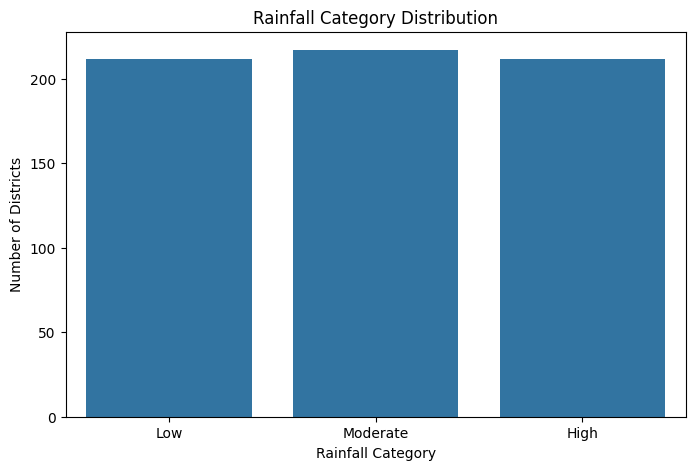

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Rainfall_Category"
)

plt.title("Rainfall Category Distribution")
plt.xlabel("Rainfall Category")
plt.ylabel("Number of Districts")

plt.show()

In [42]:
df.shape

(641, 28)

In [43]:
df.columns.tolist()

['State',
 'District',
 'Jan',
 'Feb',
 'Mar',
 'Apr',
 'May',
 'Jun',
 'Jul',
 'Aug',
 'Sep',
 'Oct',
 'Nov',
 'Dec',
 'Annual_Rainfall',
 'Jan_Feb',
 'Mar_May',
 'Jun_Sep',
 'Oct_Dec',
 'Winter_Rainfall',
 'Summer_Rainfall',
 'Monsoon_Rainfall',
 'Post_Monsoon_Rainfall',
 'Max_Monthly_Rainfall',
 'Min_Monthly_Rainfall',
 'Rainfall_STD',
 'Monsoon_Contribution',
 'Rainfall_Category']

In [44]:
df.head()

,State,District,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,...,Oct_Dec,Winter_Rainfall,Summer_Rainfall,Monsoon_Rainfall,Post_Monsoon_Rainfall,Max_Monthly_Rainfall,Min_Monthly_Rainfall,Rainfall_STD,Monsoon_Contribution,Rainfall_Category
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,...,892.1,165.2,540.7,1207.2,892.1,358.5,57.9,113.818630,43.034365,High
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,...,705.3,69.7,483.5,1757.2,705.3,457.2,18.6,178.321770,58.268395,High
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,...,574.7,48.6,405.6,1884.4,574.7,503.3,8.6,197.687826,64.682662,High
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,...,231.0,123.0,841.3,1848.5,231.0,660.1,29.8,199.235322,60.730009,High
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,...,268.1,112.8,645.4,3008.4,268.1,990.9,29.5,332.122661,74.563165,High


In [45]:
features = [
    "State",

    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",

    "Winter_Rainfall",
    "Summer_Rainfall",
    "Monsoon_Rainfall",
    "Post_Monsoon_Rainfall",

    "Max_Monthly_Rainfall",
    "Min_Monthly_Rainfall",
    "Rainfall_STD",
    "Monsoon_Contribution"
]

X = df[features]

y = df["Rainfall_Category"]

In [46]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (641, 21)
y shape: (641,)


In [47]:
numeric_features = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
    "Winter_Rainfall",
    "Summer_Rainfall",
    "Monsoon_Rainfall",
    "Post_Monsoon_Rainfall",
    "Max_Monthly_Rainfall",
    "Min_Monthly_Rainfall",
    "Rainfall_STD",
    "Monsoon_Contribution"
]

categorical_features = ["State"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [49]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (512, 21)
Testing data: (129, 21)


In [50]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [52]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [53]:
print("Decision Tree Results")

print(
    "Accuracy:",
    accuracy_score(y_test, dt_predictions)
)

print(
    "Precision:",
    precision_score(
        y_test,
        dt_predictions,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        dt_predictions,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        dt_predictions,
        average="weighted"
    )
)

Decision Tree Results
Accuracy: 0.8992248062015504
Precision: 0.9049816473850183
Recall: 0.8992248062015504
F1 Score: 0.9004724978874261


In [54]:
print(
    classification_report(
        y_test,
        dt_predictions
    )
)

              precision    recall  f1-score   support

        High       0.97      0.88      0.93        43
         Low       0.93      0.90      0.92        42
    Moderate       0.82      0.91      0.86        44

    accuracy                           0.90       129
   macro avg       0.91      0.90      0.90       129
weighted avg       0.90      0.90      0.90       129



In [55]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_estimators=200
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [56]:
print("Random Forest Results")

print(
    "Accuracy:",
    accuracy_score(y_test, rf_predictions)
)

print(
    "Precision:",
    precision_score(
        y_test,
        rf_predictions,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        rf_predictions,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        rf_predictions,
        average="weighted"
    )
)

Random Forest Results
Accuracy: 0.9534883720930233
Precision: 0.9544628936105913
Recall: 0.9534883720930233
F1 Score: 0.9537282737882675


In [57]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                kernel="rbf",
                random_state=42
            )
        )
    ]
)

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

In [58]:
print("SVM Results")

print(
    "Accuracy:",
    accuracy_score(y_test, svm_predictions)
)

print(
    "Precision:",
    precision_score(
        y_test,
        svm_predictions,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        svm_predictions,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        svm_predictions,
        average="weighted"
    )
)

SVM Results
Accuracy: 0.9689922480620154
Precision: 0.9693528033171084
Recall: 0.9689922480620154
F1 Score: 0.9690834473324214


In [59]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, svm_predictions)
    ],

    "Precision": [
        precision_score(
            y_test,
            dt_predictions,
            average="weighted"
        ),
        precision_score(
            y_test,
            rf_predictions,
            average="weighted"
        ),
        precision_score(
            y_test,
            svm_predictions,
            average="weighted"
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            dt_predictions,
            average="weighted"
        ),
        recall_score(
            y_test,
            rf_predictions,
            average="weighted"
        ),
        recall_score(
            y_test,
            svm_predictions,
            average="weighted"
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            dt_predictions,
            average="weighted"
        ),
        f1_score(
            y_test,
            rf_predictions,
            average="weighted"
        ),
        f1_score(
            y_test,
            svm_predictions,
            average="weighted"
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.899225,0.904982,0.899225,0.900472
1,Random Forest,0.953488,0.954463,0.953488,0.953728
2,SVM,0.968992,0.969353,0.968992,0.969083


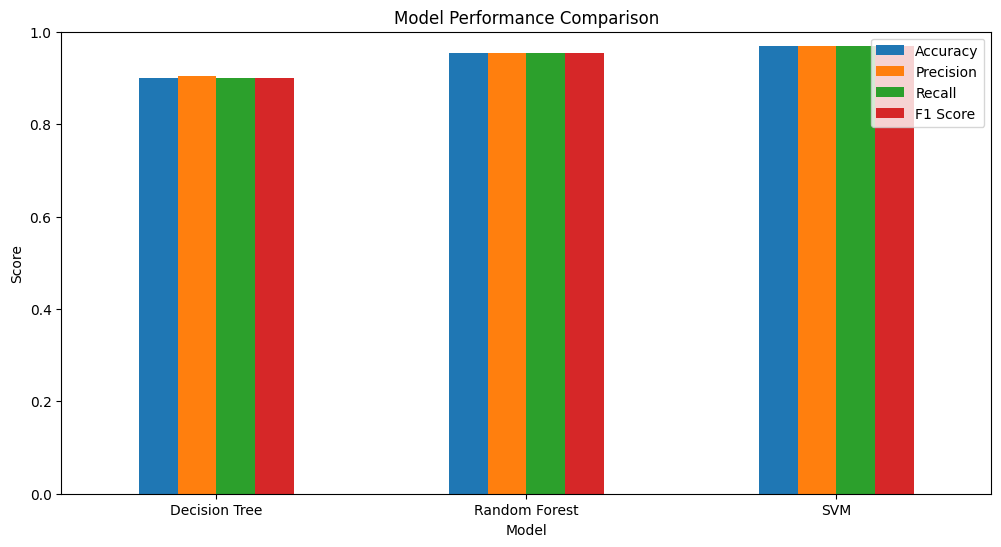

In [60]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

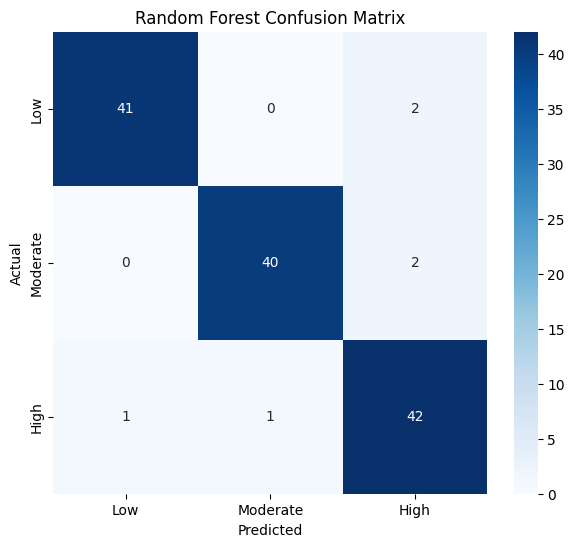

In [61]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Moderate", "High"],
    yticklabels=["Low", "Moderate", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [62]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

dt_params = {
    "classifier__max_depth": [
        3, 5, 7, 10, None
    ],

    "classifier__min_samples_split": [
        2, 5, 10
    ],

    "classifier__min_samples_leaf": [
        1, 2, 4
    ],

    "classifier__criterion": [
        "gini",
        "entropy"
    ]
}

In [63]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_params,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Jan',
                                                                          'Feb',
                                                                          'Mar',
                                                                          'Apr',
                                                                          'May',
                                                                          'Jun',
                                                                          'Jul',
                                                                          'Aug',
                                                                          'Sep',
                                                                          'Oct',
                                                                          'Nov',
                                                                          'Dec',
                                                                          'Winter_Rainfall',
                                                                          'Summer_Rainfa...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['State'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 7, 10, None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='f1_weighted')

In [64]:
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print(
    "Best CV F1:",
    dt_grid.best_score_
)

Best Decision Tree Parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}
Best CV F1: 0.9126508052701515


In [65]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

rf_params = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
        20
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [66]:
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Jan',
                                                                          'Feb',
                                                                          'Mar',
                                                                          'Apr',
                                                                          'May',
                                                                          'Jun',
                                                                          'Jul',
                                                                          'Aug',
                                                                          'Sep',
                                                                          'Oct',
                                                                          'Nov',
                                                                          'Dec',
                                                                          'Winter_Rainfall',
                                                                          'Summer_Rainfa...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['State'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10, 20],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='f1_weighted')

In [67]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print(
    "Best CV F1:",
    rf_grid.best_score_
)

Best Random Forest Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best CV F1: 0.9551236107035876


In [68]:
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC()
        )
    ]
)

svm_params = {
    "classifier__C": [
        0.1,
        1,
        10,
        100
    ],

    "classifier__gamma": [
        "scale",
        "auto"
    ],

    "classifier__kernel": [
        "rbf",
        "linear"
    ]
}

In [69]:
svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Jan',
                                                                          'Feb',
                                                                          'Mar',
                                                                          'Apr',
                                                                          'May',
                                                                          'Jun',
                                                                          'Jul',
                                                                          'Aug',
                                                                          'Sep',
                                                                          'Oct',
                                                                          'Nov',
                                                                          'Dec',
                                                                          'Winter_Rainfall',
                                                                          'Summer_Rainfa...
                                                                          'Rainfall_STD',
                                                                          'Monsoon_Contribution']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['State'])])),
                                       ('classifier', SVC())]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10, 100],
                         'classifier__gamma': ['scale', 'auto'],
                         'classifier__kernel': ['rbf', 'linear']},
             scoring='f1_weighted')

In [70]:
print("Best SVM Parameters:")
print(svm_grid.best_params_)

print(
    "Best CV F1:",
    svm_grid.best_score_
)

Best SVM Parameters:
{'classifier__C': 100, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV F1: 0.9589078734884099


In [71]:
tuned_models = {
    "Tuned Decision Tree": dt_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned SVM": svm_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    predictions = model.predict(X_test)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Decision Tree,0.914729,0.916590,0.914729,0.915048
1,Tuned Random Forest,0.961240,0.961568,0.961240,0.961318
2,Tuned SVM,0.953488,0.954590,0.953488,0.952910


In [72]:
tuned_results_df.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Tuned Random Forest,0.961240,0.961568,0.961240,0.961318
2,Tuned SVM,0.953488,0.954590,0.953488,0.952910
0,Tuned Decision Tree,0.914729,0.916590,0.914729,0.915048


In [73]:
best_model_name = tuned_results_df.loc[
    tuned_results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on weighted F1:")
print(best_model_name)

Best model based on weighted F1:
Tuned Random Forest


In [74]:
best_model = rf_grid.best_estimator_

joblib.dump(
    best_model,
    "rainfall_classifier.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [75]:
best_model = rf_grid.best_estimator_

joblib.dump(
    best_model,
    "rainfall_classifier.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [76]:
from google.colab import files

files.download("rainfall_classifier.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
df.to_csv(
    "district_rainfall_cleaned.csv",
    index=False
)

In [78]:
files.download(
    "district_rainfall_cleaned.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
loaded_model = joblib.load(
    "rainfall_classifier.pkl"
)

In [80]:
new_district = pd.DataFrame({
    "State": ["Tamil Nadu"],

    "Jan": [20],
    "Feb": [15],
    "Mar": [25],
    "Apr": [50],
    "May": [60],
    "Jun": [40],
    "Jul": [70],
    "Aug": [80],
    "Sep": [90],
    "Oct": [150],
    "Nov": [200],
    "Dec": [100],

    "Winter_Rainfall": [35],
    "Summer_Rainfall": [135],
    "Monsoon_Rainfall": [280],
    "Post_Monsoon_Rainfall": [450],

    "Max_Monthly_Rainfall": [200],
    "Min_Monthly_Rainfall": [15],
    "Rainfall_STD": [55],
    "Monsoon_Contribution": [31]
})

In [81]:
prediction = loaded_model.predict(
    new_district
)

print("Predicted Rainfall Category:")
print(prediction[0])

Predicted Rainfall Category:
Low


In [82]:
def predict_rainfall_category(
    state,
    monthly_values
):

    months = [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]

    rainfall = dict(
        zip(months, monthly_values)
    )

    winter = (
        rainfall["Jan"] +
        rainfall["Feb"]
    )

    summer = (
        rainfall["Mar"] +
        rainfall["Apr"] +
        rainfall["May"]
    )

    monsoon = (
        rainfall["Jun"] +
        rainfall["Jul"] +
        rainfall["Aug"] +
        rainfall["Sep"]
    )

    post_monsoon = (
        rainfall["Oct"] +
        rainfall["Nov"] +
        rainfall["Dec"]
    )

    annual = sum(monthly_values)

    input_data = {
        "State": state,
        **rainfall,

        "Winter_Rainfall": winter,
        "Summer_Rainfall": summer,
        "Monsoon_Rainfall": monsoon,
        "Post_Monsoon_Rainfall": post_monsoon,

        "Max_Monthly_Rainfall": max(
            monthly_values
        ),

        "Min_Monthly_Rainfall": min(
            monthly_values
        ),

        "Rainfall_STD": np.std(
            monthly_values,
            ddof=1
        ),

        "Monsoon_Contribution": (
            monsoon / annual
        ) * 100
    }

    input_df = pd.DataFrame([input_data])

    prediction = loaded_model.predict(
        input_df
    )

    return prediction[0]

In [83]:
result = predict_rainfall_category(
    "Tamil Nadu",
    [
        20, 15, 25, 50,
        60, 40, 70, 80,
        90, 150, 200, 100
    ]
)

print("Predicted Category:", result)

Predicted Category: Low


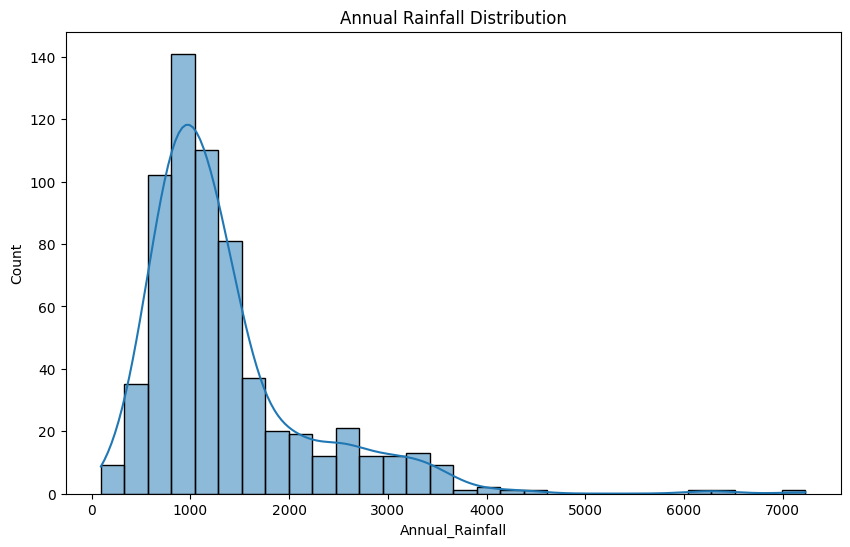

In [84]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Annual_Rainfall"],
    bins=30,
    kde=True
)

plt.title("Annual Rainfall Distribution")

plt.savefig(
    "rainfall_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()